In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.sparse import issparse
from anndata import AnnData
import scanpy as sc

In [2]:
import os

In [3]:
from tqdm.notebook import tqdm

In [4]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

In [5]:
def aggregate_auc_results(root_dir: str = ".", pathways=None, seeds=None):
    """
    Aggregate AUC results from all seed folders and pathways.
    
    Parameters
    ----------
    root_dir : str
        Root directory containing pathway folders (tgfb, tnfa)
    pathways : list, optional
        List of pathway names. Default: ['tgfb', 'tnfa']
    seeds : list, optional
        List of seed numbers. Default: [0, 1, 2]
        
    Returns
    -------
    dict
        Dictionary with structure:
        {
            'tgfb': {
                'tripso_mean_auc': float,
                'spectra_mean_auc': float,
                'difference': float
            },
            'tnfa': {
                'tripso_mean_auc': float,
                'spectra_mean_auc': float,
                'difference': float
            }
        }
    """
    if pathways is None:
        pathways = ['tgfb', 'tnfa']
    if seeds is None:
        seeds = [0, 1, 2]
    
    results = {}
    
    for pathway in pathways:
        tripso_aucs = []
        spectra_aucs = []
        
        for seed in seeds:
            # Construct the path to the CSV file
            pathway_formatted = 'TGFb' if pathway.lower() == 'tgfb' else 'TNFa'
            csv_path = os.path.join(
                root_dir,
                pathway,
                f'output_gpfinder_{seed}',
                f'attention_simple/module_score_auc_{pathway_formatted}_vs_spectra.csv'
            )
            
            # Check if file exists
            if not os.path.exists(csv_path):
                print(f"Warning: File not found: {csv_path}")
                continue
            
            # Read the CSV file
            df = pd.read_csv(csv_path)
            
            # Extract AUC values
            tripso_auc = df[df['method'] == 'tripso']['auc'].values[0]
            spectra_auc = df[df['method'] == 'spectra']['auc'].values[0]
            
            tripso_aucs.append(tripso_auc)
            spectra_aucs.append(spectra_auc)
        
        # Calculate means
        if tripso_aucs and spectra_aucs:
            tripso_mean = np.mean(tripso_aucs)
            spectra_mean = np.mean(spectra_aucs)
            
            results[pathway] = {
                'tripso_mean_auc': tripso_mean,
                'spectra_mean_auc': spectra_mean,
                'difference': tripso_mean - spectra_mean,
                'tripso_std': np.std(tripso_aucs),
                'spectra_std': np.std(spectra_aucs),
                'n_seeds': len(tripso_aucs)
            }
        else:
            print(f"Warning: No valid results found for pathway {pathway}")
    
    return results


In [6]:
auc_results = aggregate_auc_results(root_dir='.')

In [7]:
auc_results

{'tgfb': {'tripso_mean_auc': 0.6569935047383241,
  'spectra_mean_auc': 0.6152456130819167,
  'difference': 0.041747891656407354,
  'tripso_std': 0.0018070749916618274,
  'spectra_std': 0.0010542134031741599,
  'n_seeds': 3},
 'tnfa': {'tripso_mean_auc': 0.5506140688906986,
  'spectra_mean_auc': 0.6153682254069346,
  'difference': -0.06475415651623595,
  'tripso_std': 0.001988885668235006,
  'spectra_std': 0.01327350190088873,
  'n_seeds': 3}}

# Plotting

In [8]:
def plot_split_violin_gene(
    adata: AnnData,
    gene: str,
    cell_type_col: str = "cell_type",
    pathway_col: str = "target_pathway",
    palette: dict | list | None = None,
    figsize: tuple = (8, 5),
    inner: str = "quartile",
    cut: float = 0,
    scale: str = "width",
    ax: plt.Axes | None = None,
):
    """
    Plot a split violin for a single gene, grouped by cell type and split by target pathway.

    Parameters
    ----------
    adata : AnnData
        AnnData object with expression matrix in `adata.X` (cells x genes).
        Must contain `cell_type_col` and `pathway_col` in `adata.obs`.
    gene : str
        Gene name present in `adata.var_names`.
    cell_type_col : str, default "cell_type"
        Column name in `adata.obs` to use for x-axis categories.
    pathway_col : str, default "target_pathway"
        Column name in `adata.obs` to use for hue / split.
        NOTE: seaborn's split violins require exactly 2 hue levels.
    log_base : float, default np.e
        Base of the logarithm (e for natural log, 10 for log10, etc.).
    log_offset : float, default 1.0
        Value to add before log-transform (e.g. log1p -> offset = 1).
    palette : dict, list, or None, default None
        Colors for each pathway class. Options:
          - dict: {pathway_level: color}
          - list: list of colors in same order as sorted pathway levels
          - None: let seaborn choose colors.
    figsize : tuple, default (8, 5)
        Size of the matplotlib figure.
    inner : {"box", "quartile", "point", "stick", None}, default "quartile"
        Passed to `sns.violinplot` to control the inner representation.
    cut : float, default 0
        How far the violin extends past extreme data points, as a proportion.
    scale : {"area", "count", "width"}, default "width"
        How to scale the width of each violin.
    ax : matplotlib.axes.Axes, optional
        Existing Axes to plot into. If None, a new figure and axes are created.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The axes containing the plot.

    Raises
    ------
    KeyError
        If `gene`, `cell_type_col`, or `pathway_col` are not found.
    ValueError
        If `pathway_col` has more than 2 unique values (split violins need 2).
    """

    # --- Basic checks ---
    if gene not in adata.var_names:
        raise KeyError(f"Gene '{gene}' not found in adata.var_names.")

    if cell_type_col not in adata.obs:
        raise KeyError(f"Column '{cell_type_col}' not found in adata.obs.")

    if pathway_col not in adata.obs:
        raise KeyError(f"Column '{pathway_col}' not found in adata.obs.")

    # Extract expression for the gene
    # adata[:, gene].X returns (n_cells x 1)
    expr = adata[:, gene].X
    if issparse(expr):
        expr = expr.toarray()
    expr = np.asarray(expr).ravel()

    # Build tidy DataFrame for seaborn
    df = pd.DataFrame({
        "expression": expr,
        "cell_type": adata.obs[cell_type_col].astype("category"),
        "pathway": adata.obs[pathway_col].astype("category"),
    })

    # seaborn split violins require exactly 2 levels in hue
    pathway_levels = df["pathway"].cat.categories
    if len(pathway_levels) != 2:
        raise ValueError(
            f"Split violins require exactly 2 levels in '{pathway_col}', "
            f"but found {len(pathway_levels)}: {list(pathway_levels)}"
        )

    # If palette is a list, map it to pathway levels in sorted order
    if isinstance(palette, list):
        if len(palette) != len(pathway_levels):
            raise ValueError(
                "If `palette` is a list, its length must match the number of "
                f"pathway levels ({len(pathway_levels)}), but got {len(palette)}."
            )
        palette = {lvl: col for lvl, col in zip(pathway_levels, palette)}

    # Prepare axes
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    # Plot split violins
    sns.violinplot(
        data=df,
        x="cell_type",
        y="expression",
        hue="pathway",
        split=True,
        palette=palette,
        inner=inner,
        cut=cut,
        scale=scale,
        ax=ax,
    );

    # Labels
    ax.set_ylabel('Log normalized expression')
    ax.set_xlabel(cell_type_col)
    ax.set_title(f"{gene} expression by {cell_type_col} (split by {pathway_col})")
    ax.legend(title=pathway_col, bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    return ax

In [9]:
# expr = sc.read_h5ad('tripso_reproducibility/02.1_benchmarking_repeat/perturbseq/data/Jiang.h5ad')

# sc.pp.normalize_total(expr, target_sum=1e4)
# sc.pp.log1p(expr)

In [10]:
expr = sc.read_h5ad('../benchmark_repeat/Jiang_log_norm.h5ad')

In [11]:
# Subset expression data to test set
attn = sc.read_h5ad('tgfb/output_gpfinder_0/attention/HVG_attention_test_set.h5ad')
expr = expr[attn.obs["idx"].values, :]

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [12]:
expr

View of AnnData object with n_obs × n_vars = 62325 × 23083
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'cell_type', 'percent.mito', 'sample_ID', 'Batch_info', 'bc1_well', 'bc2_well', 'bc3_well', 'guide', 'gene', 'mixscale_score', 'target_pathway', 'n_counts'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'ensembl_id'
    uns: 'hvg', 'log1p'

In [13]:
# expr.write_h5ad('Jiang_log_norm.h5ad')

In [14]:
expr.obs['target_pathway'].value_counts()

target_pathway
TNFa    38589
TGFb    23736
Name: count, dtype: int64

In [15]:
pathway_palette = {
    'TGFb' : '#3A68AE',
    'TNFa' : '#E07F80',
}

In [16]:
# plot_split_violin_gene(
#     expr,
#     'MET', 
#     palette = pathway_palette
# )

# Plot module score

In [17]:
# tgfb
tgfb_clusters = pd.read_csv('tgfb/output_gpfinder_0/attention_simple/gpdb_clusters_corr.csv')

In [18]:
def plot_split_violin_module_score(
    adata: AnnData,
    module: str,
    cell_type_col: str = "cell_type",
    pathway_col: str = "target_pathway",
    palette: dict | list | None = None,
    figsize: tuple = (5, 4),
    inner: str = "quartile",
    cut: float = 0,
    scale: str = "width",
    ax: plt.Axes | None = None,
    save: str | None = None
):
    """
    Plot a split violin for a single gene, grouped by cell type and split by target pathway.

    Parameters
    ----------
    adata : AnnData
        AnnData object with expression matrix in `adata.X` (cells x genes).
        Must contain `cell_type_col` and `pathway_col` in `adata.obs`.
    gene : str
        Gene name present in `adata.var_names`.
    cell_type_col : str, default "cell_type"
        Column name in `adata.obs` to use for x-axis categories.
    pathway_col : str, default "target_pathway"
        Column name in `adata.obs` to use for hue / split.
        NOTE: seaborn's split violins require exactly 2 hue levels.
    palette : dict, list, or None, default None
        Colors for each pathway class. Options:
          - dict: {pathway_level: color}
          - list: list of colors in same order as sorted pathway levels
          - None: let seaborn choose colors.
    figsize : tuple, default (8, 5)
        Size of the matplotlib figure.
    inner : {"box", "quartile", "point", "stick", None}, default "quartile"
        Passed to `sns.violinplot` to control the inner representation.
    cut : float, default 0
        How far the violin extends past extreme data points, as a proportion.
    scale : {"area", "count", "width"}, default "width"
        How to scale the width of each violin.
    ax : matplotlib.axes.Axes, optional
        Existing Axes to plot into. If None, a new figure and axes are created.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The axes containing the plot.

    Raises
    ------
    KeyError
        If `gene`, `cell_type_col`, or `pathway_col` are not found.
    ValueError
        If `pathway_col` has more than 2 unique values (split violins need 2).
    """
    # Build tidy DataFrame for seaborn
    df = adata.obs[[module, cell_type_col, pathway_col]]
    
    df = df.rename(columns = {
        module : 'module_score',
        cell_type_col : 'cell_type', 
        pathway_col : 'pathway'
    }
                  )

    # seaborn split violins require exactly 2 levels in hue
    pathway_levels = df["pathway"].cat.categories
    if len(pathway_levels) != 2:
        raise ValueError(
            f"Split violins require exactly 2 levels in '{pathway_col}', "
            f"but found {len(pathway_levels)}: {list(pathway_levels)}"
        )

    # If palette is a list, map it to pathway levels in sorted order
    if isinstance(palette, list):
        if len(palette) != len(pathway_levels):
            raise ValueError(
                "If `palette` is a list, its length must match the number of "
                f"pathway levels ({len(pathway_levels)}), but got {len(palette)}."
            )
        palette = {lvl: col for lvl, col in zip(pathway_levels, palette)}

    # Prepare axes
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    # Plot split violins
    sns.violinplot(
        data=df,
        x="cell_type",
        y="module_score",
        hue="pathway",
        split=True,
        palette=palette,
        inner=inner,
        cut=cut,
        scale=scale,
        ax=ax,
    );

    # Labels
    ax.set_ylabel('Module score')
    ax.set_xlabel(cell_type_col)
    ax.set_title(f"{module.replace('_', ' ')}")
    ax.legend(title=pathway_col, bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.tick_params(axis="x", rotation=90)

    # Only handle layout/saving/showing if we created the figure
    if 'fig' in locals():
        plt.tight_layout()
        if save:
            plt.savefig(save)
        plt.show()
    return ax

In [19]:
def plot_module_score_boxplot(df, score_cols, palette, gp, fig_size=(10, 6), save=None):
    pathway_col = "target_pathway"  # or make this a function argument

    # Melt dataframe
    df_long = df.melt(
        id_vars=[pathway_col],
        value_vars=score_cols,
        var_name="score_type",
        value_name="score"
    )

    # Plot
    fig, ax = plt.subplots(figsize=fig_size)
    sns.boxplot(
        data=df_long,
        x="score_type",
        y="score",
        hue=pathway_col,
        palette=palette,
        ax=ax
    )

    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_title(f"GP module score\n{gp} discovery")

    # Put legend outside the plot
    ax.legend(title=pathway_col, bbox_to_anchor=(1.05, 1), loc="upper left")

    fig.tight_layout()

    if save:
        fig.savefig(save, bbox_inches="tight")

    plt.show()


In [20]:
def plot_delta_auc(
    adata: AnnData,
    pathway: str,
    auc_results: dict,
    tripso_score_col: str,
    spectra_score_col: str,
    pathway_col: str = "target_pathway",
    palette: dict | None = None,
    figsize: tuple = (6, 5),
    ax: plt.Axes | None = None,
    save: str | None = None
):
    """
    Plot boxplots comparing tripso and spectra module scores with AUC annotations and delta bar.
    
    Parameters
    ----------
    adata : AnnData
        AnnData object with module scores in obs
    pathway : str
        Pathway name ('tgfb' or 'tnfa')
    auc_results : dict
        Dictionary from aggregate_auc_results() containing AUC values
    tripso_score_col : str
        Column name in adata.obs for tripso module score
    spectra_score_col : str
        Column name in adata.obs for spectra module score
    pathway_col : str, default "target_pathway"
        Column name in adata.obs for pathway labels
    palette : dict, optional
        Colors for each pathway class
    figsize : tuple, default (6, 5)
        Size of the figure
    ax : matplotlib.axes.Axes, optional
        Existing Axes to plot into
    save : str, optional
        Path to save the figure
        
    Returns
    -------
    ax : matplotlib.axes.Axes
        The axes containing the plot
    """
    # Get AUC values for this pathway
    pathway_key = pathway.lower()
    if pathway_key not in auc_results:
        raise ValueError(f"Pathway '{pathway}' not found in auc_results")
    
    tripso_auc = auc_results[pathway_key]['tripso_mean_auc']
    spectra_auc = auc_results[pathway_key]['spectra_mean_auc']
    delta = auc_results[pathway_key]['difference']
    
    # Prepare data
    df = adata.obs[[tripso_score_col, spectra_score_col, pathway_col]].copy()
    
    # Melt for boxplot
    df_long = df.melt(
        id_vars=[pathway_col],
        value_vars=[tripso_score_col, spectra_score_col],
        var_name="method",
        value_name="module_score"
    )
    
    # Simplify method names
    df_long['method'] = df_long['method'].replace({
        tripso_score_col: 'tripso',
        spectra_score_col: 'spectra'
    })
    
    # Create figure if needed
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure
    
    # Plot boxplots
    sns.boxplot(
        data=df_long,
        x="method",
        y="module_score",
        hue=pathway_col,
        palette=palette,
        ax=ax
    )
    
    # Customize x-tick labels with AUC values
    pathway_formatted = 'TGFb' if pathway_key == 'tgfb' else 'TNFa'
    labels = [
        f'tripso\nAUC = {tripso_auc * 100:.1f}',
        f'spectra\nAUC = {spectra_auc * 100:.1f}'
    ]
    ax.set_xticklabels(labels)
    
    # Add delta bar
    y_max = df_long['module_score'].max()
    y_range = df_long['module_score'].max() - df_long['module_score'].min()
    bar_height = y_max + 0.15 * y_range
    
    # Draw horizontal lines and connecting line
    x1, x2 = 0, 1
    ax.plot([x1, x1, x2, x2], [bar_height - 0.02 * y_range, bar_height, bar_height, bar_height - 0.02 * y_range], 
            'k-', linewidth=1.5)
    
    # Add delta text
    ax.text((x1 + x2) / 2, bar_height + 0.02 * y_range, 
            f'Δ = {delta * 100:.1f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Labels and title
    ax.set_ylabel('Module score')
    ax.set_xlabel('')
    ax.set_title(f'{pathway_formatted} module score comparison')
    ax.legend(title=pathway_col, bbox_to_anchor=(1.05, 1), loc="upper left")
    
    # Adjust y-axis to accommodate the bar
    ax.set_ylim(df_long['module_score'].min() - 0.05 * y_range, 
                bar_height + 0.1 * y_range)
    
    if 'fig' in locals() and ax.figure == fig:
        plt.tight_layout()
        if save:
            plt.savefig(save, bbox_inches='tight')
        plt.show()
    
    return ax

# TGFb

In [21]:
for gp in tqdm(tgfb_clusters.columns, desc="Computing module scores"):
    sc.tl.score_genes(
            expr,
            gene_list=tgfb_clusters[gp].dropna().tolist(),
            score_name=f"{gp}_module_score",
        )    

Computing module scores:   0%|          | 0/6 [00:00<?, ?it/s]

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/scanpy/tools/_score_genes.py:169: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(


/tmp/ipykernel_2914637/2588760071.py:89: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_2914637/2588760071.py:89: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_2914637/2588760071.py:89: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_2914637/2588760071.py:89: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_2914637/2588760071.py:89: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_29146

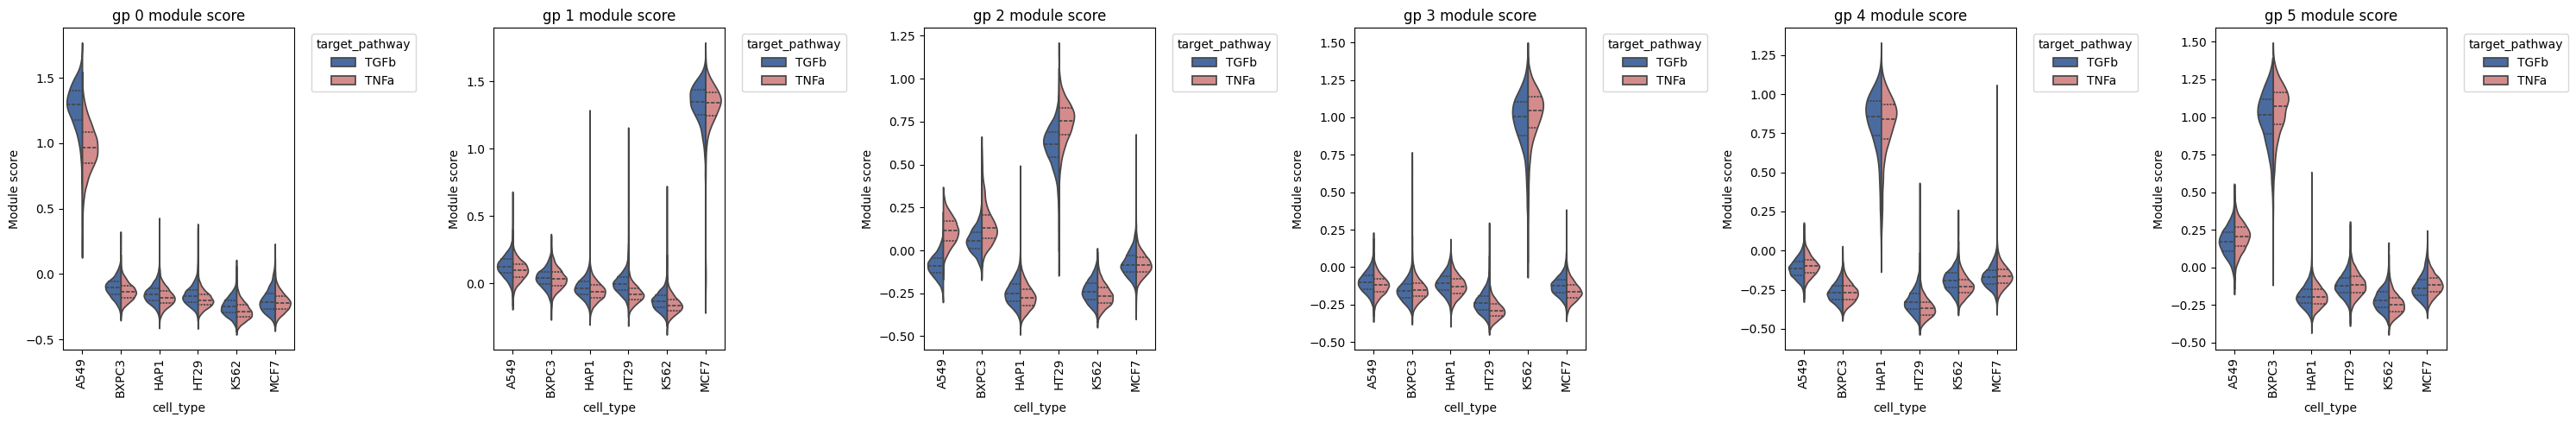

In [22]:
# Create a grid layout with 2 rows
gp_list = tgfb_clusters.columns.tolist()
n_gps = len(gp_list)
# n_cols = int(np.ceil(n_gps / 2))
n_cols = n_gps

fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))
axes = axes.flatten()

for i, gp in enumerate(gp_list):
    plot_split_violin_module_score(
        expr, 
        module=f"{gp}_module_score", 
        palette=pathway_palette,
        ax=axes[i]
    )

# Hide any extra subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('tgfb_all_clusters_grid.pdf', bbox_inches='tight')
plt.show()

In [23]:
tgfb_score_cols = []
for gp in tgfb_clusters.columns:
    tgfb_score_cols.append(f"{gp}_module_score")
    

In [24]:
spectra = sc.read_h5ad('/lustre/scratch126/cellgen/lotfollahi/cs60/proj_gpfinder/benchmark_global/tgfb/seed_0/spectra_out.h5ad')

In [25]:
index_labels = spectra.uns['SPECTRA_overlap'].index
gene_weights = pd.DataFrame(spectra.uns['SPECTRA_factors'],
                            index= index_labels,
                            columns=spectra.var[spectra.var['spectra_vocab']].index)

gene_weights_t = gene_weights.T

In [26]:
sc.tl.score_genes(
        expr,
        gene_list=gene_weights_t[gene_weights_t['2-X-TGFb-X-2'] > 0.25].index.tolist(),
        score_name=f"spectra_tgfb_module_score",
    )    

/tmp/ipykernel_2914637/1500165701.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


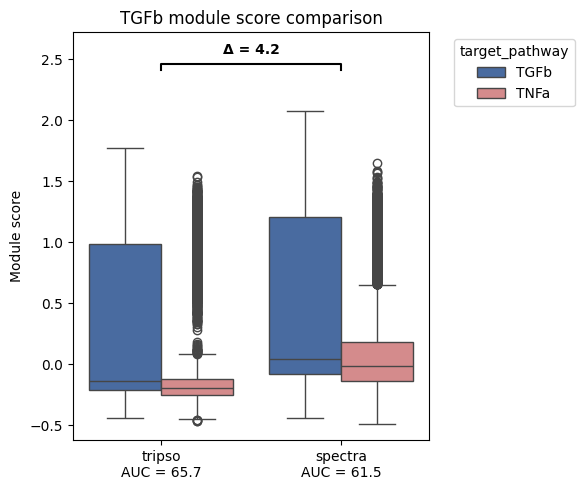

<Axes: title={'center': 'TGFb module score comparison'}, ylabel='Module score'>

In [27]:
plot_delta_auc(
    adata=expr,
    pathway='tgfb',
    auc_results=auc_results,
    tripso_score_col='gp_0_module_score',
    spectra_score_col='spectra_tgfb_module_score',
    palette=pathway_palette,
    save='tgfb_delta_auc.pdf'
)


# TNFa

In [28]:
# tnfa
tnfa_clusters = pd.read_csv('tnfa/output_gpfinder_0/attention_simple/gpdb_clusters_corr.csv')

In [29]:
for gp in tqdm(tnfa_clusters.columns, desc="Computing module scores"):
    sc.tl.score_genes(
            expr,
            gene_list=tnfa_clusters[gp].dropna().tolist(),
            score_name=f"{gp}_TNFa_module_score",
        )    

Computing module scores:   0%|          | 0/6 [00:00<?, ?it/s]

/tmp/ipykernel_2914637/2588760071.py:89: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_2914637/2588760071.py:89: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_2914637/2588760071.py:89: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_2914637/2588760071.py:89: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_2914637/2588760071.py:89: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_29146

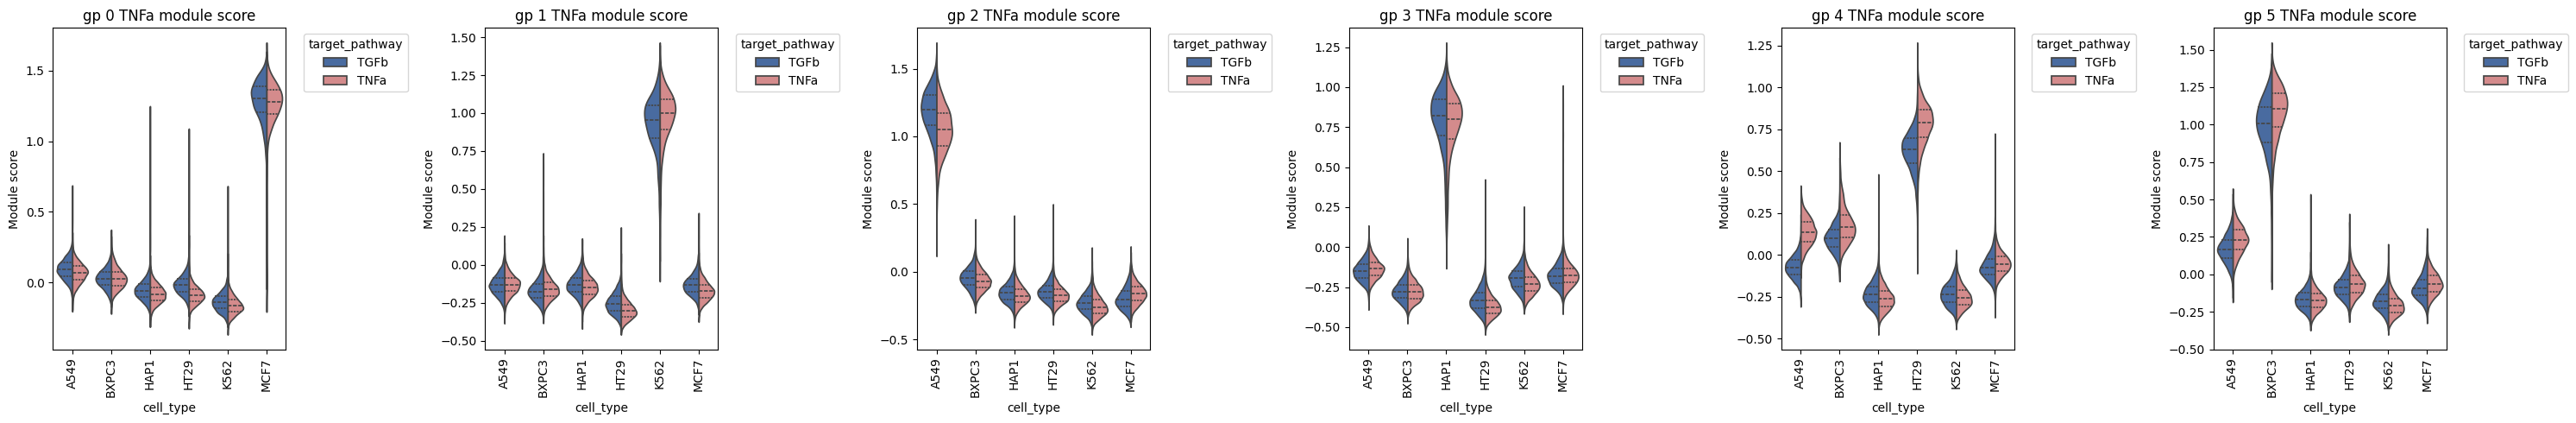

In [30]:
# Create a grid layout with 2 rows
gp_list = tnfa_clusters.columns.tolist()
n_gps = len(gp_list)
# n_cols = int(np.ceil(n_gps / 2))
n_cols = n_gps

fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))
axes = axes.flatten()

for i, gp in enumerate(gp_list):
    plot_split_violin_module_score(
        expr, 
        module=f"{gp}_TNFa_module_score", 
        palette=pathway_palette,
        ax=axes[i]
    )

# Hide any extra subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('tnfa_all_clusters_grid.pdf', bbox_inches='tight')
plt.show()

In [31]:
spectra = sc.read_h5ad('/lustre/scratch126/cellgen/lotfollahi/cs60/proj_gpfinder/benchmark_global/tnfa/seed_0/spectra_out.h5ad')

In [32]:
index_labels = spectra.uns['SPECTRA_overlap'].index
gene_weights = pd.DataFrame(spectra.uns['SPECTRA_factors'],
                            index= index_labels,
                            columns=spectra.var[spectra.var['spectra_vocab']].index)

gene_weights_t = gene_weights.T

In [33]:
gene_weights_t

,0-X-global-X-TGFb,1-X-global-X-1,2-X-TGFb-X-2,3-X-TNFa-X-3
CFH,7.672782e-02,1.040036e-01,0.075586,0.097687
CFTR,9.790566e-18,6.159021e-04,0.307341,0.078056
HS3ST1,8.133027e-17,6.090652e-04,0.192455,0.198823
KLHL13,1.517577e-02,1.920415e-01,0.002679,0.001107
SLC7A2,5.657731e-14,2.128769e-01,0.036610,0.038589
...,...,...,...,...
POTEC,1.447819e-16,9.972184e-04,0.000997,0.000997
RPTN,1.446643e-16,9.972452e-04,0.000997,0.000997
ZNF80,1.474926e-16,9.970780e-04,0.000997,0.000997
KRT75,1.499785e-16,9.972266e-04,0.000997,0.000997


In [34]:
sc.tl.score_genes(
        expr,
        gene_list=gene_weights_t[gene_weights_t['3-X-TNFa-X-3'] > 0.2].index.tolist(),
        score_name=f"spectra_TNFa_module_score",
    )    

/tmp/ipykernel_2914637/1500165701.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


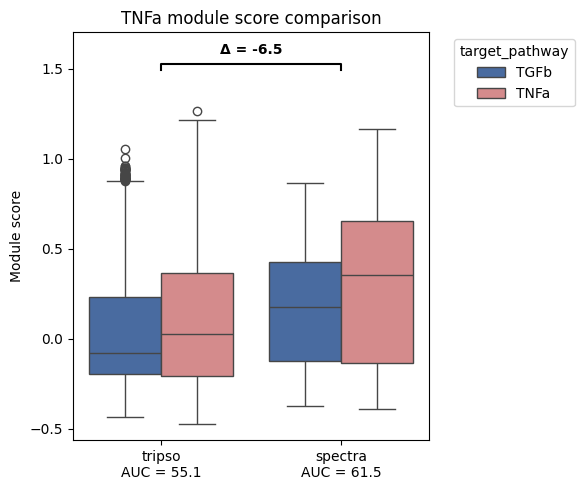

<Axes: title={'center': 'TNFa module score comparison'}, ylabel='Module score'>

In [35]:
plot_delta_auc(
    adata=expr,
    pathway='tnfa',
    auc_results=auc_results,
    tripso_score_col='gp_4_TNFa_module_score',
    spectra_score_col='spectra_TNFa_module_score',
    palette=pathway_palette,
    save='tnfa_delta_auc.pdf'
)


/tmp/ipykernel_2914637/2588760071.py:89: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


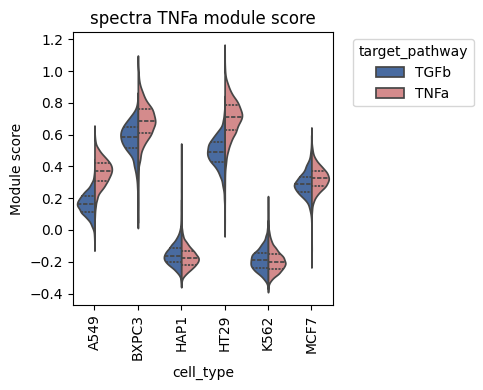

<Axes: title={'center': 'spectra TNFa module score'}, xlabel='cell_type', ylabel='Module score'>

In [36]:
plot_split_violin_module_score(
    expr, 
    module='spectra_TNFa_module_score',
    palette=pathway_palette,
)
